Loading California Housing Dataset...

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  

Dataset Shape:
(20640, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   Av

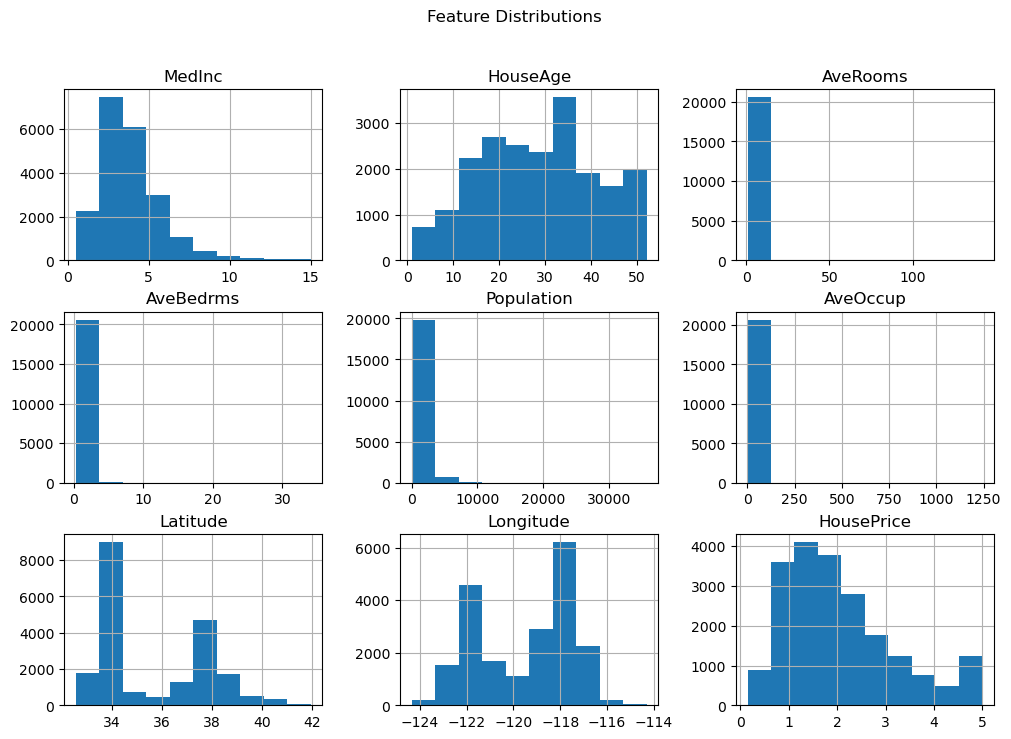

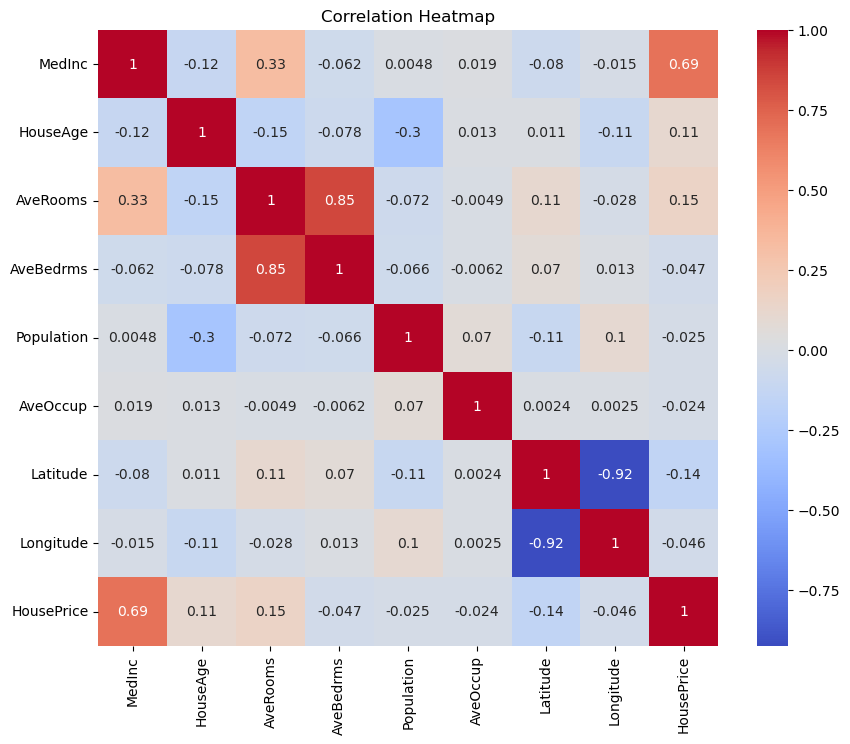


Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)

Model Training Completed

===== MODEL PERFORMANCE =====
Mean Absolute Error (MAE): 0.533
Root Mean Squared Error (RMSE): 0.746
R2 Score: 0.576


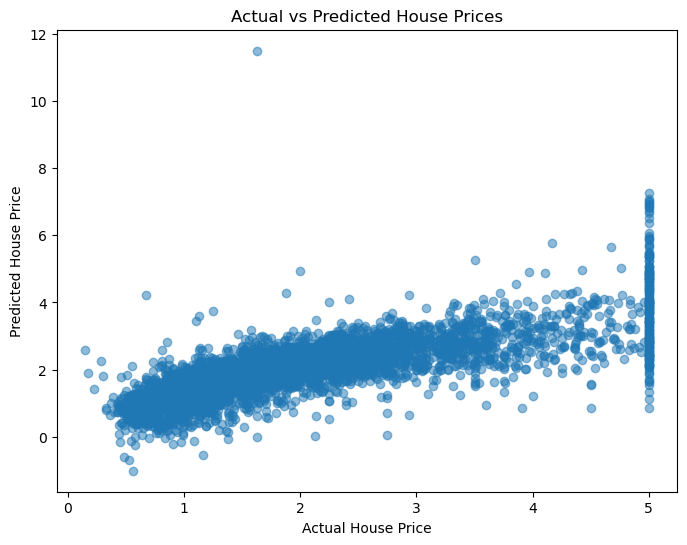

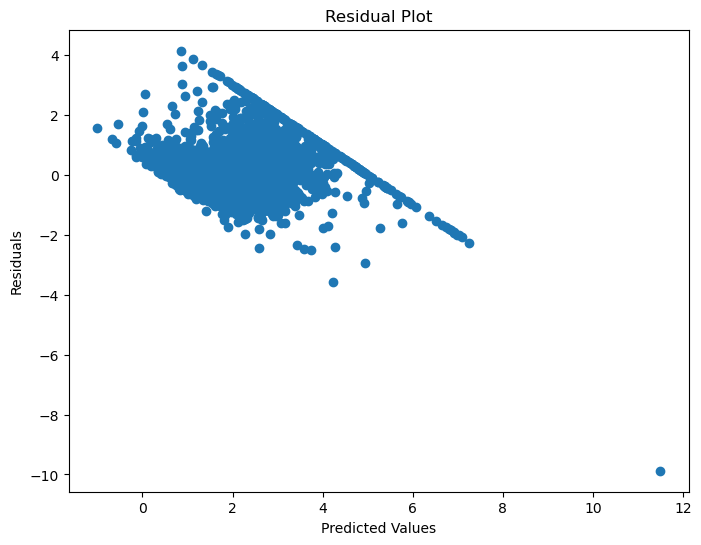


Sample Predictions:
    Actual  Predicted
0  0.47700   0.719123
1  0.45800   1.764017
2  5.00001   2.709659
3  2.18600   2.838926
4  2.78000   2.604657
5  1.58700   2.011754
6  1.98200   2.645500
7  1.57500   2.168755
8  3.40000   2.740746
9  4.46600   3.915615

Project Completed Successfully!


In [3]:
# HOUSE PRICE PREDICTION PROJECT
# LINEAR REGRESSION MODEL
# ============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================
# LOAD DATASET
# ============================

print("Loading California Housing Dataset...")

housing = fetch_california_housing(as_frame=True)

df = pd.concat(
    [housing.data,
     housing.target.rename("HousePrice")],
    axis=1
)

print("\nFirst 5 Rows:")
print(df.head())

# ============================
# DATASET INFORMATION
# ============================

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ============================
# CHECK MISSING VALUES
# ============================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================
# EXPLORATORY DATA ANALYSIS
# ============================

# Histogram
df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ============================
# FEATURE SELECTION
# ============================

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# ============================
# TRAIN TEST SPLIT
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ============================
# MODEL TRAINING
# ============================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")

# ============================
# PREDICTION
# ============================

y_pred = model.predict(X_test)

# ============================
# MODEL EVALUATION
# ============================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print("Mean Absolute Error (MAE):", round(mae,3))
print("Root Mean Squared Error (RMSE):", round(rmse,3))
print("R2 Score:", round(r2,3))

# ============================
# ACTUAL VS PREDICTED
# ============================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

# ============================
# RESIDUAL PLOT
# ============================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

# ============================
# SAMPLE PREDICTIONS
# ============================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nSample Predictions:")
print(results.head(10))

print("\nProject Completed Successfully!")

In [4]:
import os
print(os.getcwd())

C:\Users\nages\Task1_Linear_Regression
